# 01 — Data Understanding and Exploration

## 1. Study Context and Continuous Regression Objective

Concrete compressive strength is a central quantitative property used to characterize concrete performance. The **Concrete Compressive Strength** dataset from the UCI Machine Learning Repository provides **1,030 observations** described by **eight quantitative input variables**: seven concrete-mixture component quantities and curing age. The response is the measured **concrete compressive strength in MPa**.

The primary analytical objective of this study is to estimate concrete compressive strength as a **continuous numerical target** from the available mixture composition and age variables. The target will therefore remain on its original quantitative scale rather than being discretized into strength classes or converted into a classification problem.

The dataset authors describe compressive strength as a highly nonlinear function of age and ingredients. This makes the dataset a useful reference case for studying **continuous regression**, where predictive quality depends not only on detecting association but also on representing nonlinear relationships, interactions, differing feature scales, and the magnitude of numerical prediction errors.

This first notebook is intentionally limited to **data understanding and exploratory analysis**. It will establish the empirical evidence needed for later preparation and modeling decisions without fitting or selecting predictive models. Particular attention will be given to data quality, the distribution and range of the continuous target, numerical feature behavior, feature redundancy, feature-to-target relationships, possible nonlinear structure, repeated observations, and potential sources of leakage.

The analysis is predictive rather than causal. Associations observed between mixture components, age, and compressive strength should not by themselves be interpreted as causal effects, engineering design rules, or evidence that changing one component while holding all others fixed would produce the same effect in practice.

The study is guided by the following questions:

- What is the observed distribution, range, and concentration of concrete compressive strength, and are there extreme target values that may materially affect regression evaluation?
- How do the available mixture components and curing age relate to the continuous target, and which relationships appear linear, monotonic, nonlinear, or interaction-dependent?
- Which input variables are strongly related or structurally redundant, and what implications might those relationships have for later preparation and model selection?
- Are there duplicate or repeated observational profiles that could create optimistic validation if later data partitions are constructed without accounting for them?
- Which exploratory findings should guide the later split strategy, preprocessing policy, regression metrics, candidate model families, and final evaluation protocol?

## 2. Dataset Source and Acquisition

In [1]:
import pandas as pd

from scripts.download_data import acquire_uci_dataset
from scripts.project_context import get_project_context


# Dataset-specific source choices remain visible in the notebook.
DATASET_SLUG = "concrete-compressive-strength"
UCI_DATASET_ID = 165

PROJECT = get_project_context()
RAW_DATA_DIR = PROJECT.path("data", "raw", DATASET_SLUG)

acquisition = acquire_uci_dataset(
    dataset_id=UCI_DATASET_ID,
    destination=RAW_DATA_DIR,
    project_root=PROJECT.root,
)

DATASET_FILE = acquisition.require_one_file("dataset.csv")
df = pd.read_csv(DATASET_FILE)

print(f"Dataset source: UCI ML Repository — ID {UCI_DATASET_ID}")
print(f"Raw data directory: {PROJECT.display(RAW_DATA_DIR)}")
print(f"Dataset file: {DATASET_FILE.name}")
print(f"Loaded shape: {df.shape}")

Dataset source: UCI ML Repository — ID 165
Raw data directory: data/raw/concrete-compressive-strength
Dataset file: dataset.csv
Loaded shape: (1030, 9)


## 3. Unit of Observation

In [2]:
from scripts.validate_data import analyze_observation_unit


# Dataset-specific analytical definition remains visible.
OBSERVATION_LABEL = (
    "concrete mix composition evaluated at a specified curing age "
    "with measured compressive strength"
)
OBSERVATION_IDENTIFIER = None

observation_report = analyze_observation_unit(
    dataframe=df,
    identifier=OBSERVATION_IDENTIFIER,
)

print(f"Unit of observation: {OBSERVATION_LABEL}")
observation_report.summary_frame()

Unit of observation: concrete mix composition evaluated at a specified curing age with measured compressive strength


,Metric,Value
0,Rows,1030
1,Source identifier,Not provided
2,Identifier completeness,Not assessable
3,Identifier uniqueness,Not assessable


## 4. Dataset Structure and Source Identity

In [3]:
from IPython.display import display

from scripts.describe_dataset import describe_dataset_structure


structure_report = describe_dataset_structure(
    df,
    acquisition=acquisition,
    expected_source_id=UCI_DATASET_ID,
)

display(structure_report.summary_frame())
display(structure_report.columns_frame())

,Metric,Value
0,Dataset,Concrete Compressive Strength
1,Source,UCI Machine Learning Repository
2,Source dataset ID,165
3,DOI,10.24432/C5PK67
4,Rows,1030
5,Columns,9
6,Source-declared instances,1030
7,Materialized data file,data/raw/concrete-compressive-strength/dataset...


,Position,Column
0,1,Cement
1,2,Blast Furnace Slag
2,3,Fly Ash
3,4,Water
4,5,Superplasticizer
5,6,Coarse Aggregate
6,7,Fine Aggregate
7,8,Age
8,9,Concrete compressive strength


## 5. Target and Continuous Regression Prediction Contract

In [4]:
from IPython.display import display

from scripts.target_contract import define_continuous_regression_target_contract


# Dataset-specific prediction semantics remain explicit in the notebook.
TARGET_COLUMN = "Concrete compressive strength"
PROBLEM_TYPE = "continuous_regression"
TARGET_SEMANTICS = "Continuous / quantitative"
TARGET_UNIT = "MPa"
SOURCE_TARGET_TYPE = "Continuous"

target_contract = define_continuous_regression_target_contract(
    df,
    target=TARGET_COLUMN,
    problem_type=PROBLEM_TYPE,
    target_semantics=TARGET_SEMANTICS,
    expected_unit=TARGET_UNIT,
    expected_source_type=SOURCE_TARGET_TYPE,
    source_variables_file=acquisition.require_one_file("variables.csv"),
)

display(target_contract.summary_frame())

,Contract item,Value,Interpretation
0,Problem type,continuous_regression,Supervised continuous regression task
1,Target column,Concrete compressive strength,Continuous outcome to be predicted
2,Target semantics,Continuous / quantitative,Quantitative target; not a class label
3,Prediction output,Continuous numeric value on the original targe...,No thresholding or class decoding applies
4,Target unit,MPa,Unit of the original prediction scale
5,Source variable role,Target,Role declared by source metadata
6,Source variable type,Continuous,Type declared by source metadata
7,Contract status,Valid,"Target exists, is numeric, and matches declare..."


## 6. Feature Roles and Data Dictionary

In [5]:
from scripts.feature_dictionary import define_feature_roles_and_dictionary


feature_dictionary = define_feature_roles_and_dictionary(
    df,
    source_variables_file=acquisition.require_one_file("variables.csv"),
    target=target_contract.target,
    identifiers=OBSERVATION_IDENTIFIER,
)

FEATURE_COLUMNS = feature_dictionary.feature_columns
IDENTIFIER_COLUMNS = feature_dictionary.identifier_columns

display(feature_dictionary.summary_frame())
feature_dictionary.column_frame()

,Metric,Value
0,Candidate features,8
1,Identifiers,0
2,Targets,1
3,Columns covered by source metadata,9
4,Columns with source descriptions,0


,Column,Analytical role,Source role,Description,Unit
0,Cement,Candidate feature,Feature,Not documented by source,kg/m^3
1,Blast Furnace Slag,Candidate feature,Feature,Not documented by source,kg/m^3
2,Fly Ash,Candidate feature,Feature,Not documented by source,kg/m^3
3,Water,Candidate feature,Feature,Not documented by source,kg/m^3
4,Superplasticizer,Candidate feature,Feature,Not documented by source,kg/m^3
5,Coarse Aggregate,Candidate feature,Feature,Not documented by source,kg/m^3
6,Fine Aggregate,Candidate feature,Feature,Not documented by source,kg/m^3
7,Age,Candidate feature,Feature,Not documented by source,day
8,Concrete compressive strength,Target,Target,Not documented by source,MPa


## 7. Data Types, Ranges, and Domain Validity

In [6]:
from scripts.validate_domains import analyze_types_ranges_and_domains


# Dataset-specific physical and source-documented constraints remain visible.
DOMAIN_RULES = {
    "non_negative": (
        "Cement",
        "Blast Furnace Slag",
        "Fly Ash",
        "Water",
        "Superplasticizer",
        "Coarse Aggregate",
        "Fine Aggregate",
        "Concrete compressive strength",
    ),
    "minimums": {
        "Age": 1.0,
    },
    "maximums": {
        "Age": 365.0,
    },
}

domain_report = analyze_types_ranges_and_domains(
    df,
    source_variables_file=acquisition.require_one_file("variables.csv"),
    domain_rules=DOMAIN_RULES,
)

display(domain_report.summary_frame())
display(domain_report.column_frame())
domain_report.relation_frame()

,Metric,Value
0,Columns with source-backed type expectations,9
1,Type mismatches,1
2,Columns with declared domain expectations,9
3,Columns with domain violations,0
4,Declared cross-column relations,0
5,Relations with violations,0


,Column,Source type,Expected type,Observed dtype,Observed minimum,Observed maximum,Domain expectation,Violation count,Status
0,Cement,Continuous,numeric,float64,102.00,540.0,>= 0,0,Valid
1,Blast Furnace Slag,Integer,integer,float64,0.00,359.4,>= 0,0,Review required
2,Fly Ash,Continuous,numeric,float64,0.00,200.1,>= 0,0,Valid
3,Water,Continuous,numeric,float64,121.80,247.0,>= 0,0,Valid
4,Superplasticizer,Continuous,numeric,float64,0.00,32.2,>= 0,0,Valid
5,Coarse Aggregate,Continuous,numeric,float64,801.00,1145.0,>= 0,0,Valid
6,Fine Aggregate,Continuous,numeric,float64,594.00,992.6,>= 0,0,Valid
7,Age,Integer,integer,int64,1.00,365.0,>= 1; <= 365,0,Valid
8,Concrete compressive strength,Continuous,numeric,float64,2.33,82.6,>= 0,0,Valid


,Relation,Evaluated rows,Violation count,Status


## 8. Missing and Invalid Values

In [7]:
from scripts.validate_values import analyze_source_backed_missing_and_invalid_values


value_quality_report = analyze_source_backed_missing_and_invalid_values(
    df,
    source_variables_file=acquisition.require_one_file("variables.csv"),
    target=target_contract.target,
)

# In exploration, discovered issues remain evidence rather than being mutated away.
value_quality_report.raise_if_invalid(require_no_quality_issues=False)

display(value_quality_report.summary_frame())
display(value_quality_report.column_frame())
value_quality_report.issues_with_impacts_frame()

,Status,Column count
0,Valid,8
1,Review required,1
2,Not assessed,0
3,Missing column,0


,Column,Row count,Missing count,Blank count,Inconsistent count,Invalid count,Affected count,Affected percent,Issue types,Status
0,Cement,1030,0,0,0,0,0,0.000,,Valid
1,Blast Furnace Slag,1030,0,0,0,298,298,28.932,Non-integer value,Review required
2,Fly Ash,1030,0,0,0,0,0,0.000,,Valid
3,Water,1030,0,0,0,0,0,0.000,,Valid
4,Superplasticizer,1030,0,0,0,0,0,0.000,,Valid
5,Coarse Aggregate,1030,0,0,0,0,0,0.000,,Valid
6,Fine Aggregate,1030,0,0,0,0,0,0.000,,Valid
7,Age,1030,0,0,0,0,0,0.000,,Valid
8,Concrete compressive strength,1030,0,0,0,0,0,0.000,,Valid


,Column,Issue,Raw value,Count,Potential analytical impact
0,Blast Furnace Slag,Non-integer value,106.3,20,Violates a source-declared integer field and m...
1,Blast Furnace Slag,Non-integer value,98.1,10,Violates a source-declared integer field and m...
2,Blast Furnace Slag,Non-integer value,132.4,6,Violates a source-declared integer field and m...
3,Blast Furnace Slag,Non-integer value,142.5,6,Violates a source-declared integer field and m...
4,Blast Furnace Slag,Non-integer value,203.5,6,Violates a source-declared integer field and m...
5,Blast Furnace Slag,Non-integer value,209.4,6,Violates a source-declared integer field and m...
6,Blast Furnace Slag,Non-integer value,237.5,6,Violates a source-declared integer field and m...
7,Blast Furnace Slag,Non-integer value,47.5,6,Violates a source-declared integer field and m...
8,Blast Furnace Slag,Non-integer value,97.1,6,Violates a source-declared integer field and m...
9,Blast Furnace Slag,Non-integer value,117.2,5,Violates a source-declared integer field and m...


## 9. Duplicate Records

In [8]:
from scripts.validate_duplicates import analyze_duplicate_records


duplicate_report = analyze_duplicate_records(
    df,
    identifiers=IDENTIFIER_COLUMNS,
    feature_columns=FEATURE_COLUMNS,
    target=target_contract.target,
    max_group_samples=10,
)

display(duplicate_report.summary_frame())

if not duplicate_report.has_source_identifiers:
    print(
        "Source identifiers are not available. Exact row matches are "
        "review evidence, not proof that the same concrete observation "
        "was recorded twice."
    )

if duplicate_report.has_exact_duplicates:
    print("Sample of exact row matches:")
    display(duplicate_report.exact_duplicates_frame())

if duplicate_report.has_repeated_profiles:
    print("Sample of repeated candidate-feature profiles:")
    display(duplicate_report.repeated_profiles_frame())

if duplicate_report.has_target_conflicts:
    print(
        "Some identical feature profiles map to different compressive-strength "
        "values. Treat these cases as analytical ambiguity or observed "
        "measurement/process variability rather than automatic data-quality "
        "errors."
    )
    display(duplicate_report.target_conflicts_frame())

# Without source identifiers, equality alone does not justify dropping rows.
duplicate_report.raise_if_invalid(
    require_no_exact_duplicates=bool(IDENTIFIER_COLUMNS),
    require_unique_identifiers=bool(IDENTIFIER_COLUMNS),
    require_no_conflicting_identifiers=bool(IDENTIFIER_COLUMNS),
    require_no_repeated_profiles=False,
    require_no_target_conflicts=False,
)

,Metric,Group count,Row count,Interpretation
0,Exact duplicate records,11,36,Review required; source identity unavailable
1,Duplicate identifiers,0,0,Not applicable; source identifier unavailable
2,Conflicting duplicate identifiers,0,0,Not applicable; source identifier unavailable
3,Repeated feature profiles,19,57,Potentially valid repeated records
4,Repeated profiles with the same target,10,33,Valid repeated profile
5,Repeated profiles with target disagreement,9,24,Analytical ambiguity


Source identifiers are not available. Exact row matches are review evidence, not proof that the same concrete observation was recorded twice.
Sample of exact row matches:


,Group,Group size,Row position,Row index,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,1,3,72,72,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3.0,33.40
1,1,3,77,77,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3.0,33.40
2,1,3,80,80,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3.0,33.40
3,2,4,83,83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.30
4,2,4,86,86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.30
5,2,4,88,88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.30
6,2,4,91,91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.30
7,3,3,95,95,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7.0,49.20
8,3,3,100,100,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7.0,49.20
9,3,3,103,103,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7.0,49.20


Sample of repeated candidate-feature profiles:


,Profile group,Row count,Distinct identifier count,Target values,Target value count,Classification,Row positions,Row indices,Feature values
0,1,3,<NA>,np.float64(33.4),1,Same target,"(72, 77, 80)","(72, 77, 80)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
1,2,4,<NA>,np.float64(35.3),1,Same target,"(83, 86, 88, 91)","(83, 86, 88, 91)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."
2,3,3,<NA>,np.float64(49.2),1,Same target,"(95, 100, 103)","(95, 100, 103)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
3,4,4,<NA>,"np.float64(55.9), np.float64(22.9)",2,Target disagreement,"(106, 109, 111, 114)","(106, 109, 111, 114)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."
4,5,3,<NA>,np.float64(60.29),1,Same target,"(118, 123, 126)","(118, 123, 126)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
5,6,4,<NA>,np.float64(71.3),1,Same target,"(129, 132, 134, 137)","(129, 132, 134, 137)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."
6,7,3,<NA>,np.float64(64.3),1,Same target,"(141, 146, 149)","(141, 146, 149)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
7,8,4,<NA>,np.float64(77.3),1,Same target,"(152, 155, 157, 160)","(152, 155, 157, 160)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."
8,9,3,<NA>,np.float64(65.2),1,Same target,"(164, 169, 172)","(164, 169, 172)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
9,10,4,<NA>,np.float64(79.3),1,Same target,"(175, 177, 179, 182)","(175, 177, 179, 182)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."


Some identical feature profiles map to different compressive-strength values. Treat these cases as analytical ambiguity or observed measurement/process variability rather than automatic data-quality errors.


,Profile group,Row count,Distinct identifier count,Target values,Target value count,Classification,Row positions,Row indices,Feature values
0,4,4,<NA>,"np.float64(55.9), np.float64(22.9)",2,Target disagreement,"(106, 109, 111, 114)","(106, 109, 111, 114)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."


## 10. Target Distribution, Range, and Extremes

,Metric,Value,Interpretation
0,Total rows,1030.000000,All observations
1,Finite target values,1030.000000,Rows used for numerical summaries
2,Missing target values,0.000000,No missing target values
3,Non-finite target values,0.000000,All non-missing target values are finite
4,Distinct finite values,845.000000,Observed target-value diversity
5,Minimum,2.330000,Observed minimum (MPa)
6,Mean,35.817961,Arithmetic mean (MPa)
7,Median,34.445000,50th percentile (MPa)
8,Maximum,82.600000,Observed maximum (MPa)
9,Observed range,80.270000,Maximum minus minimum (MPa)


,Quantile,Value,Unit
0,1%,6.8858,MPa
1,5%,10.9610,MPa
2,25%,23.7100,MPa
3,50%,34.4450,MPa
4,75%,46.1350,MPa
5,95%,66.8020,MPa
6,99%,77.3000,MPa


,Side,Fence,Observed extreme,Count outside fence
0,Lower,-9.9275,2.33,0
1,Upper,79.7725,82.60,4


Values outside the 1.5-IQR fences are descriptive extreme-value signals only; they are not automatic outlier-removal candidates.


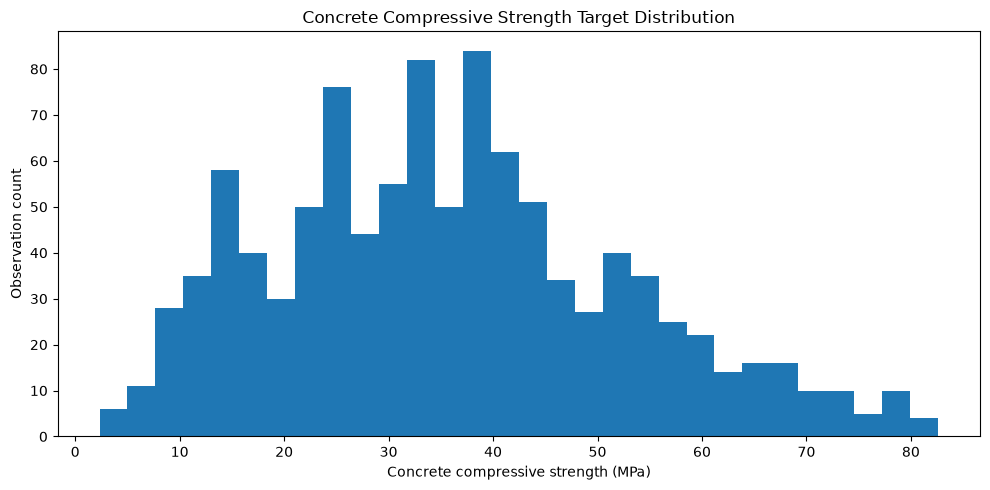

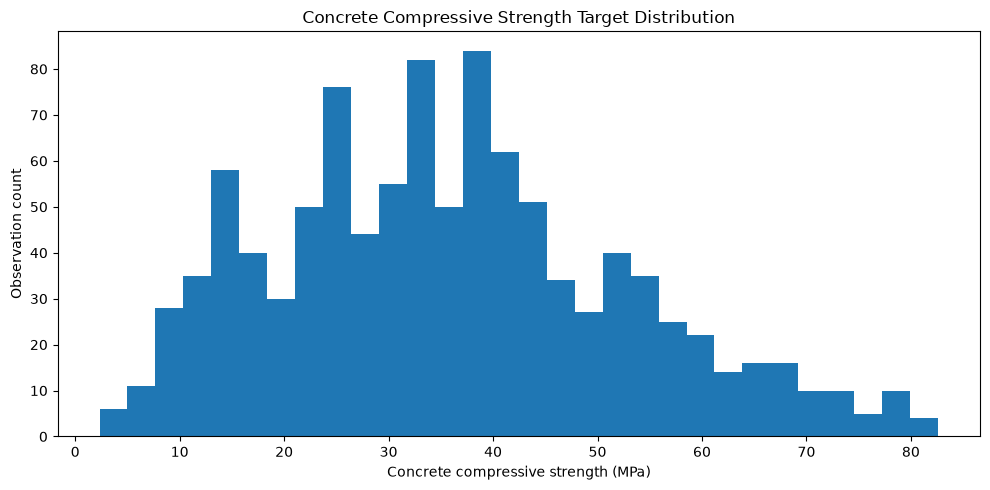

In [9]:
from scripts.export_figures import export_figure
from scripts.analyze_target import (
    analyze_continuous_target_distribution,
    plot_continuous_target_distribution,
)


target_distribution_report = analyze_continuous_target_distribution(
    df,
    target=target_contract.target,
    unit=TARGET_UNIT,
)

# Revalidate the continuous target before interpreting its distribution.
target_distribution_report.raise_if_invalid()

display(target_distribution_report.summary_frame())
display(target_distribution_report.quantiles_frame())
display(target_distribution_report.extremes_frame())

print(
    "Values outside the 1.5-IQR fences are descriptive extreme-value "
    "signals only; they are not automatic outlier-removal candidates."
)

target_distribution_figure = plot_continuous_target_distribution(
    target_distribution_report,
    title="Concrete Compressive Strength Target Distribution",
    bins=30,
)
export_figure(
    target_distribution_figure,
    PROJECT.root / "docs/images/target_distribution.png",
)
target_distribution_figure

## 11. Numerical Feature Exploration

,Feature,Minimum,Q1,Median,Mean,Q3,Maximum,Standard deviation,IQR,Skewness,Distribution shape,Outlier count,Outlier percent
0,Cement,102.0,192.375,272.9,281.167864,350.00,540.0,104.506364,157.625,0.509481,Right-skewed,0,0.00%
1,Blast Furnace Slag,0.0,0.000,22.0,73.895825,142.95,359.4,86.279342,142.950,0.800717,Right-skewed,2,0.19%
2,Fly Ash,0.0,0.000,0.0,54.188350,118.30,200.1,63.997004,118.300,0.537354,Right-skewed,0,0.00%
3,Water,121.8,164.900,185.0,181.567282,192.00,247.0,21.354219,27.100,0.074628,Approximately symmetric,9,0.87%
4,Superplasticizer,0.0,0.000,6.4,6.204660,10.20,32.2,5.973841,10.200,0.907203,Right-skewed,10,0.97%
5,Coarse Aggregate,801.0,932.000,968.0,972.918932,1029.40,1145.0,77.753954,97.400,-0.040220,Approximately symmetric,0,0.00%
6,Fine Aggregate,594.0,730.950,779.5,773.580485,824.00,992.6,80.175980,93.050,-0.253010,Approximately symmetric,5,0.49%
7,Age,1.0,7.000,28.0,45.662136,56.00,365.0,63.169912,49.000,3.269177,Right-skewed,59,5.73%


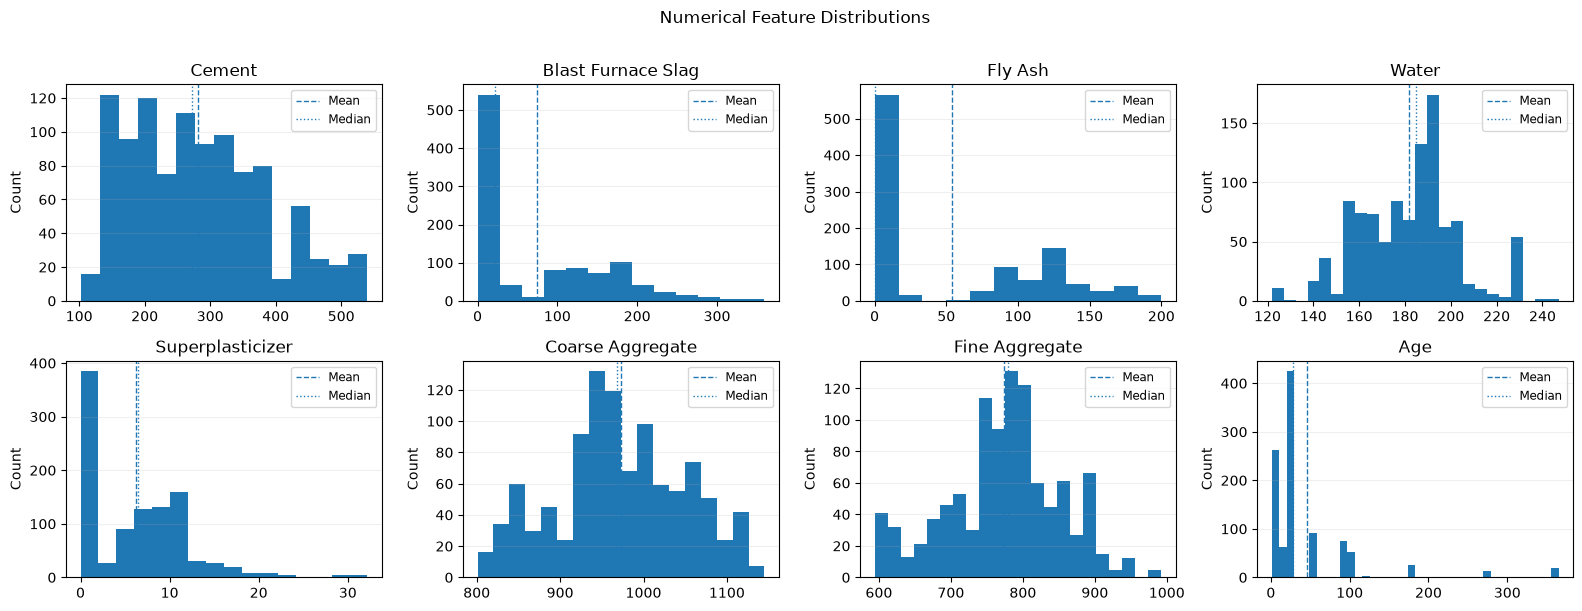

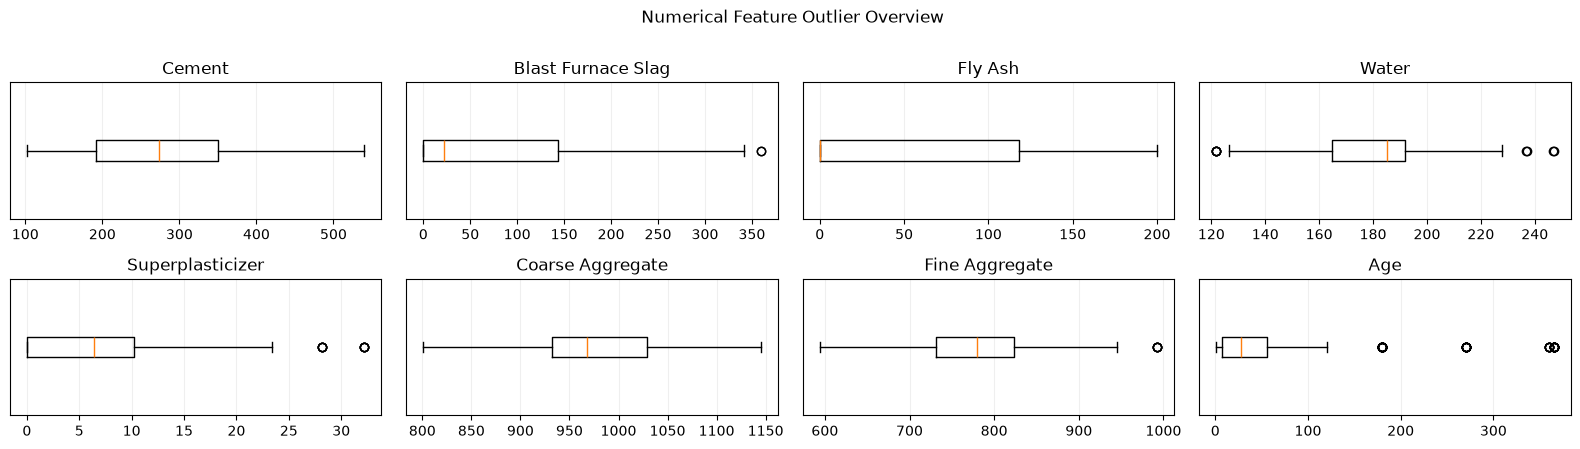

IQR candidates are descriptive evidence only; no rows are removed or clipped during exploration.


,Feature,Lower fence,Upper fence,Lower outlier count,Upper outlier count,Outlier count,Outlier percent,Interpretation
0,Cement,-44.0625,586.4375,0,0,0,0.000000,No IQR outlier candidates
1,Blast Furnace Slag,-214.4250,357.3750,0,2,2,0.001942,Candidate outliers require contextual review
2,Fly Ash,-177.4500,295.7500,0,0,0,0.000000,No IQR outlier candidates
3,Water,124.2500,232.6500,5,4,9,0.008738,Candidate outliers require contextual review
4,Superplasticizer,-15.3000,25.5000,0,10,10,0.009709,Candidate outliers require contextual review
5,Coarse Aggregate,785.9000,1175.5000,0,0,0,0.000000,No IQR outlier candidates
6,Fine Aggregate,591.3750,963.5750,0,5,5,0.004854,Candidate outliers require contextual review
7,Age,-66.5000,129.5000,0,59,59,0.057282,Candidate outliers require contextual review


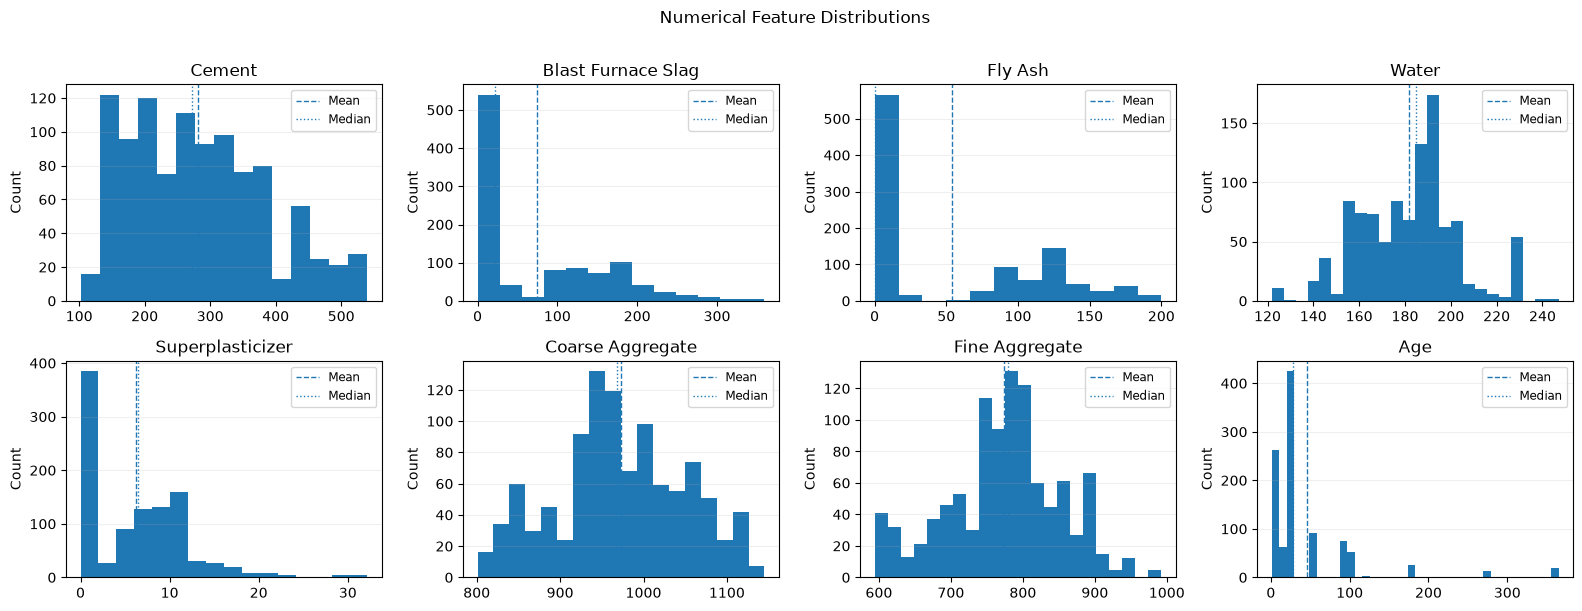

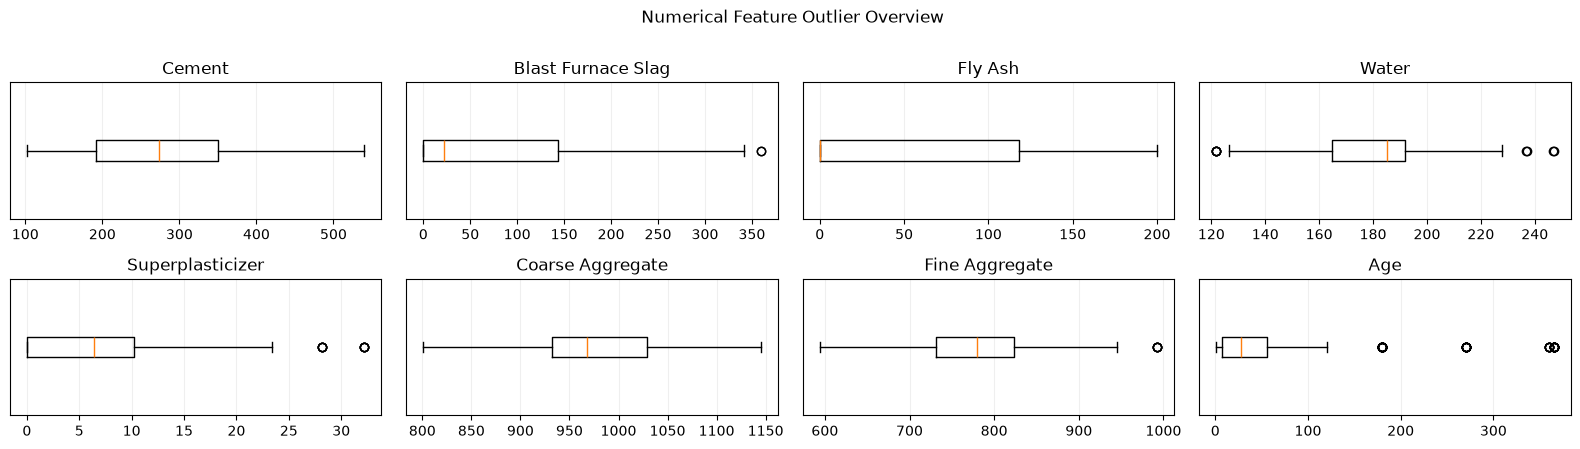

In [10]:
from IPython.display import display

from scripts.analyze_numerical import (
    analyze_numerical_features,
    plot_numerical_boxplots,
    plot_numerical_distributions,
)


# The validated candidate-feature set is entirely numerical for Concrete.
NUMERICAL_FEATURES = FEATURE_COLUMNS

# Explicit exploratory heuristics; neither one changes the raw data.
IQR_MULTIPLIER = 1.5
SKEWNESS_REVIEW_THRESHOLD = 0.5

numerical_report = analyze_numerical_features(
    df,
    features=NUMERICAL_FEATURES,
    iqr_multiplier=IQR_MULTIPLIER,
)

numerical_report.raise_if_invalid(
    require_features_present=True,
    require_numeric_conversion=True,
    require_materialization_conditions=True,
    require_no_missing_values=True,
    require_no_outliers=False,
)

display(
    numerical_report.exploration_frame(
        skewness_review_threshold=SKEWNESS_REVIEW_THRESHOLD,
    )
)

distribution_figure = plot_numerical_distributions(
    numerical_report,
    columns=4,
)
display(distribution_figure)

outlier_figure = plot_numerical_boxplots(
    numerical_report,
    columns=4,
)
display(outlier_figure)

if numerical_report.has_outliers:
    print(
        "IQR candidates are descriptive evidence only; no rows are removed "
        "or clipped during exploration."
    )
    display(numerical_report.outlier_summary_frame())

## 12. Feature Relationships and Redundancy

,Metric,Value,Interpretation
0,Numerical features,8.0,Candidate features included in the analysis
1,Feature pairs,28.0,Unique numerical feature pairs assessed
2,Strong-association threshold,0.8,Absolute Pearson or rank correlation used for ...
3,Strong-association pairs,0.0,Pairs meeting the exploratory threshold
4,Redundancy-review threshold,0.9,Absolute Pearson correlation used to flag redu...
5,Redundancy-review candidates,0.0,Review evidence only; no feature removal is im...


No feature pairs reached the strong-association review threshold.


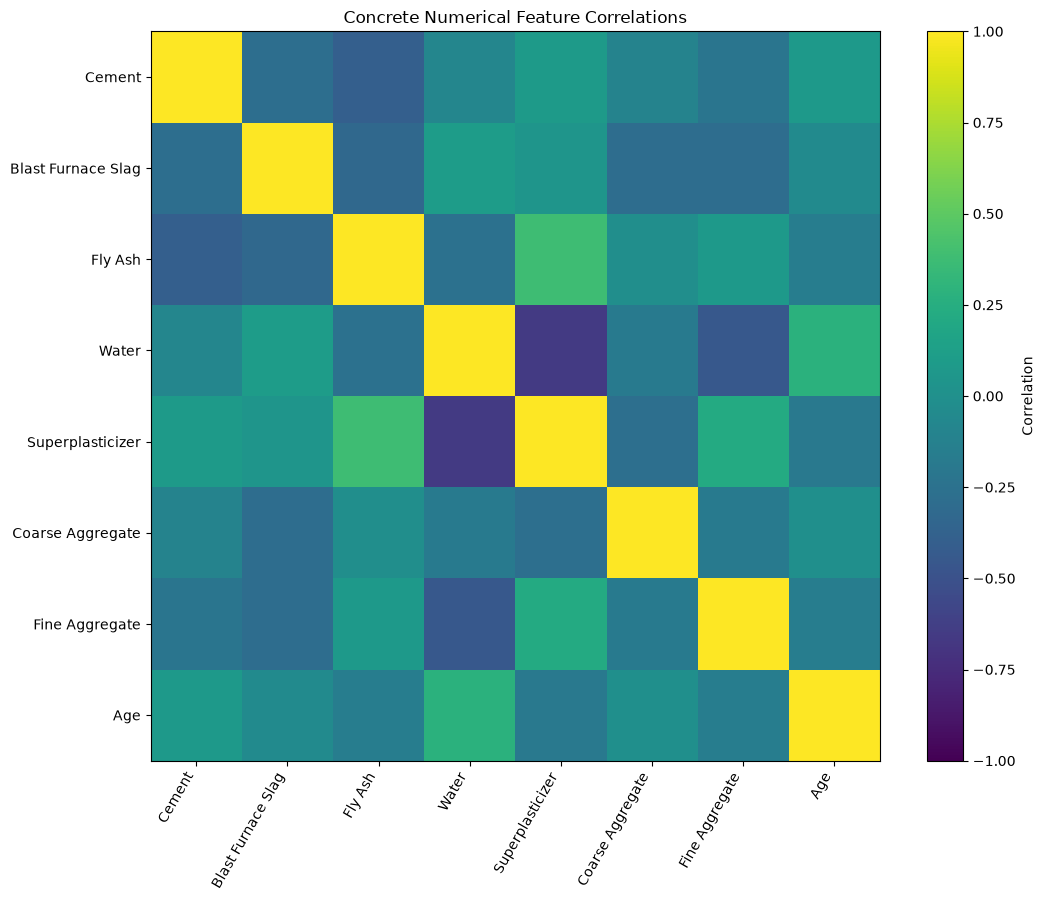

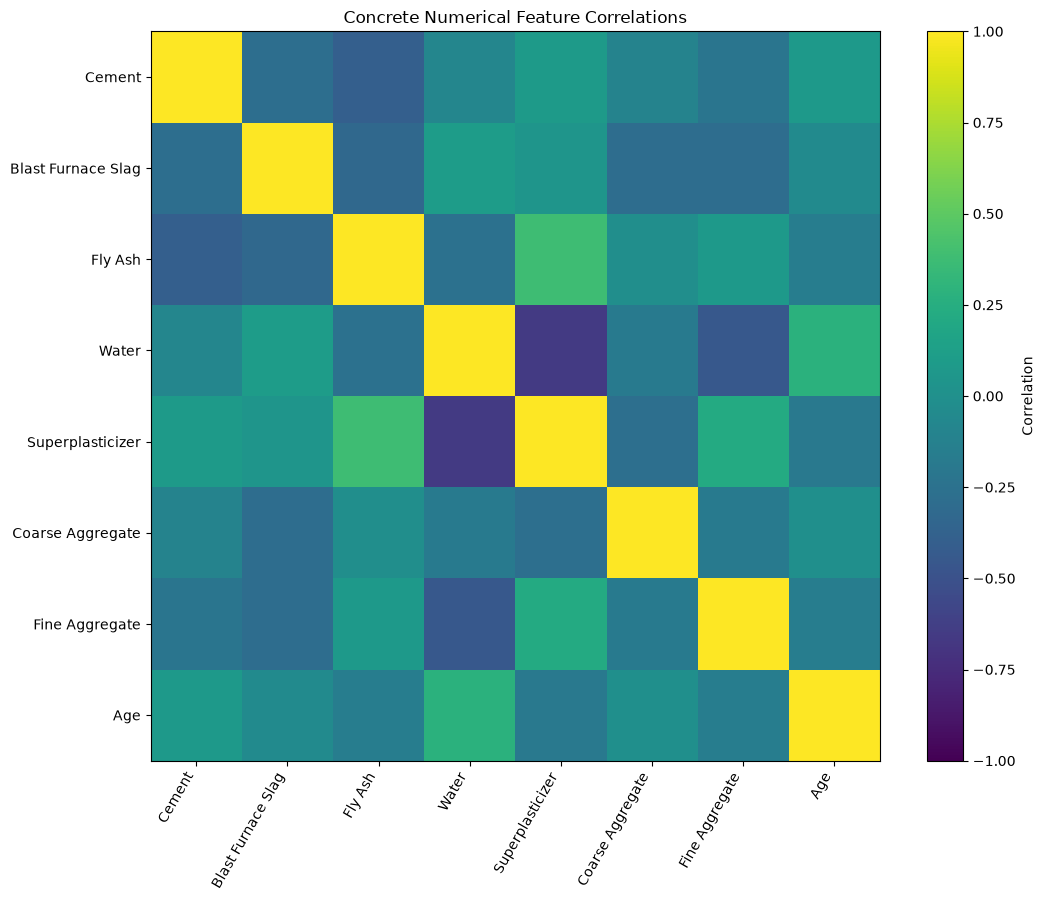

In [11]:
from scripts.analyze_relationships import (
    analyze_numerical_feature_relationships,
    plot_numerical_correlation_heatmap,
)
from scripts.export_figures import export_figure


# Exploratory thresholds remain explicit; they flag review candidates only.
STRONG_FEATURE_ASSOCIATION_THRESHOLD = 0.80
REDUNDANCY_REVIEW_THRESHOLD = 0.90

feature_relationship_report = analyze_numerical_feature_relationships(
    df,
    features=NUMERICAL_FEATURES,
    strong_association_threshold=STRONG_FEATURE_ASSOCIATION_THRESHOLD,
    redundancy_review_threshold=REDUNDANCY_REVIEW_THRESHOLD,
)

feature_relationship_report.raise_if_invalid(
    require_features_present=True,
    require_sufficient_variation=True,
)

display(feature_relationship_report.numerical_summary_frame())

relationship_review = feature_relationship_report.numerical_review_frame()
if relationship_review.empty:
    print("No feature pairs reached the strong-association review threshold.")
else:
    display(relationship_review)

correlation_figure = plot_numerical_correlation_heatmap(
    feature_relationship_report,
    method="pearson",
    title="Concrete Numerical Feature Correlations",
)
export_figure(
    correlation_figure,
    PROJECT.root / "docs/images/numerical_feature_correlation_heatmap.png",
)
display(correlation_figure)

if feature_relationship_report.has_redundancy_candidates:
    print(
        "High association marks redundancy candidates for later review; "
        "no feature is removed during exploration."
    )

## 13. Feature-to-Target Relationships

,Metric,Value,Interpretation
0,Rows,1030,Observations supplied to the analysis
1,Numerical features,8,Candidate numerical features requested
2,Target,Concrete compressive strength (MPa),Continuous regression outcome
3,Target unique values,845,Observed finite numerical target values
4,Association review threshold,0.3,"Applied to max(|Pearson|, |Spearman|); review ..."
5,Review candidates,4,Features meeting the exploratory association t...


,Feature,Valid paired rows,Excluded paired rows,Pearson correlation,Spearman correlation,Absolute Pearson correlation,Absolute Spearman correlation,Maximum absolute association,Review flag,Interpretation
0,Age,1030,0,0.328873,0.596028,0.328873,0.596028,0.596028,True,Meets the exploratory univariate association r...
1,Cement,1030,0,0.497832,0.477614,0.497832,0.477614,0.497832,True,Meets the exploratory univariate association r...
2,Superplasticizer,1030,0,0.366079,0.347786,0.366079,0.347786,0.366079,True,Meets the exploratory univariate association r...
3,Water,1030,0,-0.289633,-0.308414,0.289633,0.308414,0.308414,True,Meets the exploratory univariate association r...
4,Coarse Aggregate,1030,0,-0.164935,-0.183542,0.164935,0.183542,0.183542,False,Below the exploratory univariate association r...
5,Fine Aggregate,1030,0,-0.167241,-0.179962,0.167241,0.179962,0.179962,False,Below the exploratory univariate association r...
6,Blast Furnace Slag,1030,0,0.134829,0.164105,0.134829,0.164105,0.164105,False,Below the exploratory univariate association r...
7,Fly Ash,1030,0,-0.105755,-0.077830,0.105755,0.077830,0.105755,False,Below the exploratory univariate association r...


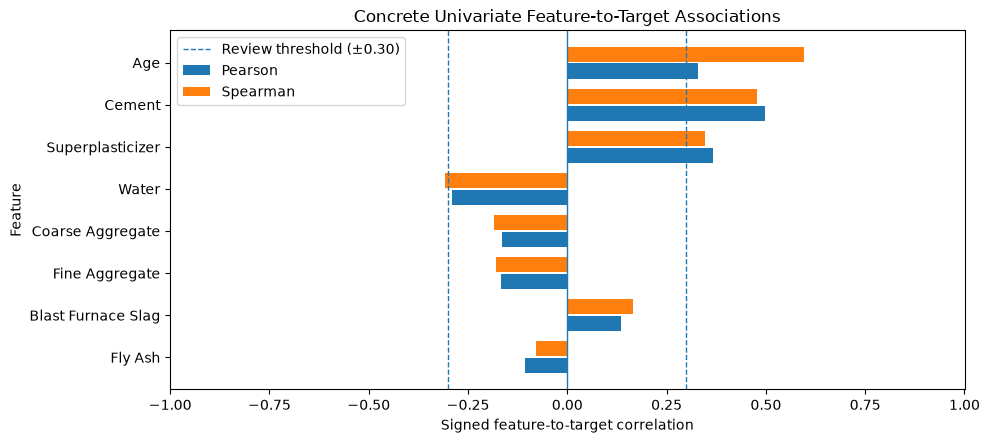

Review candidates show univariate linear or monotonic association only; no feature is selected or removed at this stage.


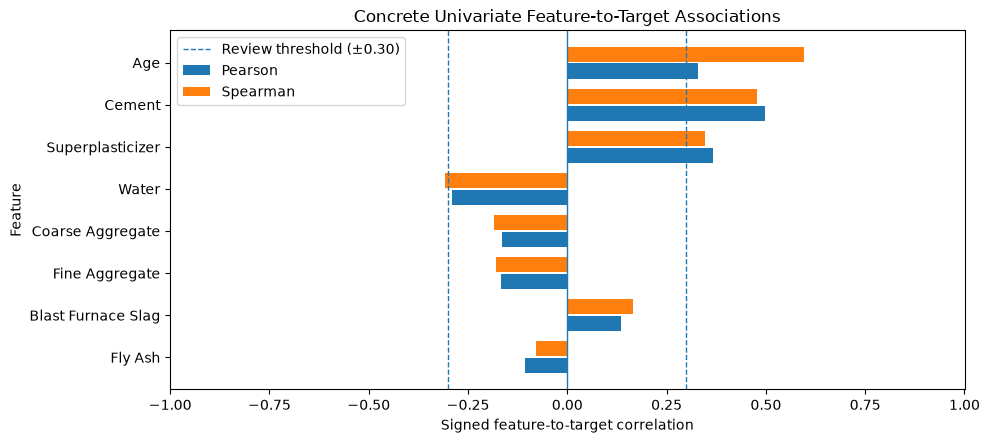

In [12]:
from scripts.analyze_target_relationships import (
    analyze_continuous_numerical_target_relationships,
    plot_continuous_feature_target_associations,
)
from scripts.export_figures import export_figure


# Exploratory association strength used for review, not feature selection.
CONTINUOUS_ASSOCIATION_REVIEW_THRESHOLD = 0.30

feature_target_report = analyze_continuous_numerical_target_relationships(
    df,
    features=NUMERICAL_FEATURES,
    target=target_contract.target,
    unit=TARGET_UNIT,
    association_review_threshold=CONTINUOUS_ASSOCIATION_REVIEW_THRESHOLD,
)

feature_target_report.raise_if_invalid(
    require_features_present=True,
    require_numeric_target=True,
    require_no_missing_target=True,
    require_target_variation=True,
    require_sufficient_feature_variation=True,
)

display(feature_target_report.summary_frame())
display(feature_target_report.relationships_frame())

association_figure = plot_continuous_feature_target_associations(
    feature_target_report,
    title="Concrete Univariate Feature-to-Target Associations",
)
export_figure(
    association_figure,
    PROJECT.root / "docs/images/feature_target_association_ranking.png",
)
display(association_figure)

if feature_target_report.has_review_candidates:
    print(
        "Review candidates show univariate linear or monotonic association "
        "only; no feature is selected or removed at this stage."
    )

## 14. Regression Structure, Nonlinearity, and Interaction Signals

,Metric,Value,Interpretation
0,Rows,1030.00,Observations supplied to the diagnostics
1,Requested numerical features,8.00,Candidate features reviewed
2,Nonlinearity review threshold,0.02,Minimum adjusted-R² gain from adding a quadrat...
3,Nonlinearity signals,3.00,Features meeting the exploratory threshold
4,Interaction review threshold,0.02,Minimum adjusted-R² gain from adding a product...
5,Interaction signals,4.00,Feature pairs meeting the exploratory threshold


,Feature,Valid rows,Excluded rows,Linear R squared,Quadratic R squared,Linear adjusted R squared,Quadratic adjusted R squared,Adjusted R squared gain,Nonlinearity signal,Interpretation
0,Age,1030,0,0.108157,0.256755,0.107290,0.255308,0.148018,True,Quadratic term adds notable descriptive structure
1,Water,1030,0,0.083887,0.137419,0.082996,0.135739,0.052743,True,Quadratic term adds notable descriptive structure
2,Blast Furnace Slag,1030,0,0.018179,0.040124,0.017224,0.038255,0.021031,True,Quadratic term adds notable descriptive structure
3,Coarse Aggregate,1030,0,0.027203,0.037360,0.026257,0.035486,0.009228,False,No notable quadratic gain at the review threshold
4,Fly Ash,1030,0,0.011184,0.020767,0.010222,0.018860,0.008637,False,No notable quadratic gain at the review threshold
5,Fine Aggregate,1030,0,0.027970,0.031678,0.027024,0.029792,0.002768,False,No notable quadratic gain at the review threshold
6,Superplasticizer,1030,0,0.134014,0.134241,0.133171,0.132555,-0.000617,False,No notable quadratic gain at the review threshold
7,Cement,1030,0,0.247837,0.247908,0.247105,0.246443,-0.000662,False,No notable quadratic gain at the review threshold


,Feature A,Feature B,Valid rows,Excluded rows,Quadratic main-effects adjusted R squared,With interaction adjusted R squared,Adjusted R squared gain,Interaction signal,Interpretation
0,Blast Furnace Slag,Superplasticizer,1030,0,0.150532,0.176730,0.026199,True,Product term adds structure beyond quadratic m...
1,Fly Ash,Coarse Aggregate,1030,0,0.056421,0.079129,0.022708,True,Product term adds structure beyond quadratic m...
2,Cement,Blast Furnace Slag,1030,0,0.346721,0.368391,0.021670,True,Product term adds structure beyond quadratic m...
3,Blast Furnace Slag,Water,1030,0,0.167856,0.188946,0.021090,True,Product term adds structure beyond quadratic m...
4,Coarse Aggregate,Fine Aggregate,1030,0,0.072048,0.091320,0.019272,False,No notable interaction gain at the review thre...
5,Superplasticizer,Fine Aggregate,1030,0,0.199514,0.217049,0.017535,False,No notable interaction gain at the review thre...
6,Fly Ash,Water,1030,0,0.176784,0.190044,0.013260,False,No notable interaction gain at the review thre...
7,Fly Ash,Superplasticizer,1030,0,0.228305,0.240108,0.011803,False,No notable interaction gain at the review thre...
8,Water,Superplasticizer,1030,0,0.168732,0.179673,0.010941,False,No notable interaction gain at the review thre...
9,Cement,Fine Aggregate,1030,0,0.249012,0.259324,0.010312,False,No notable interaction gain at the review thre...


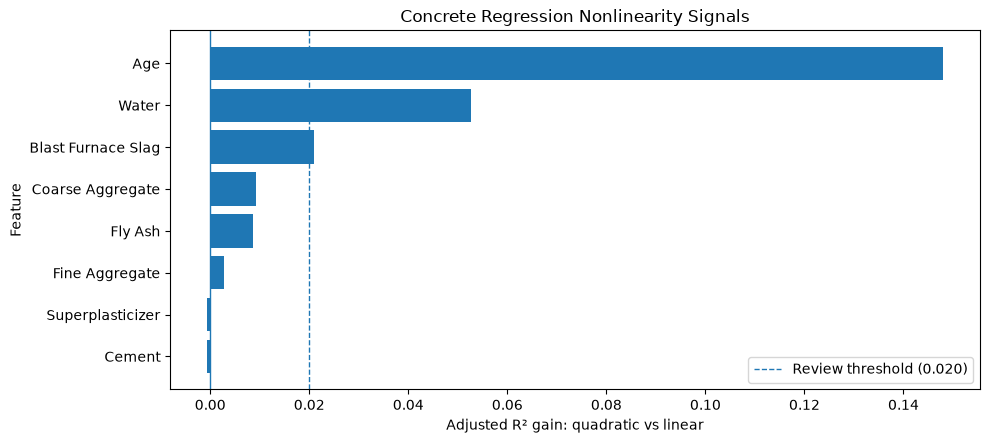

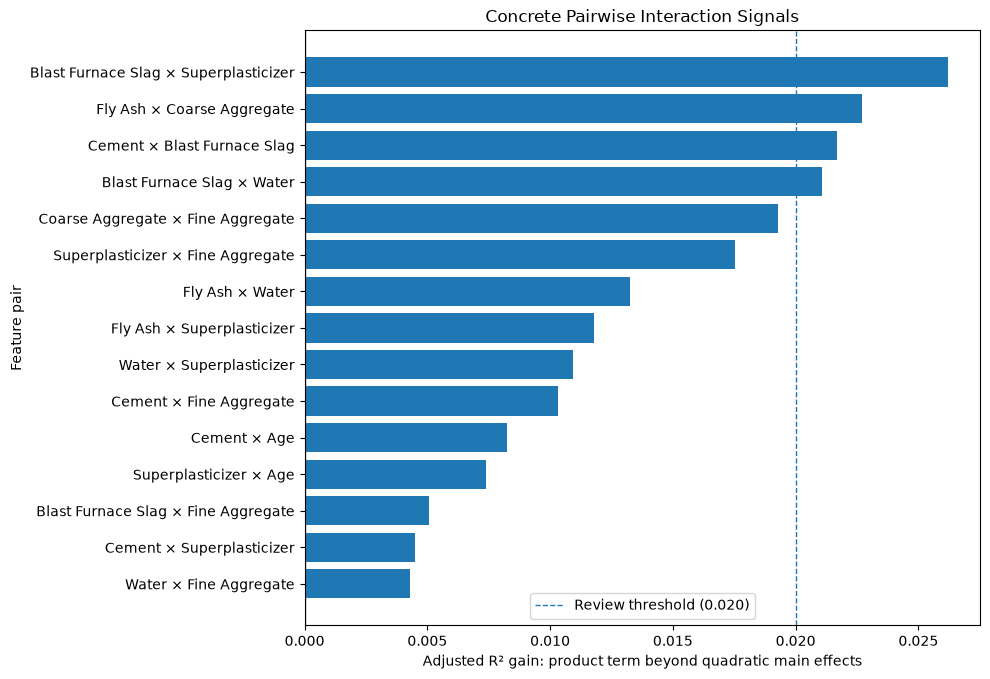

Adjusted-R² gains are in-sample structural diagnostics only. They do not estimate future predictive performance, establish causality, select features, or prescribe polynomial/interaction engineering.


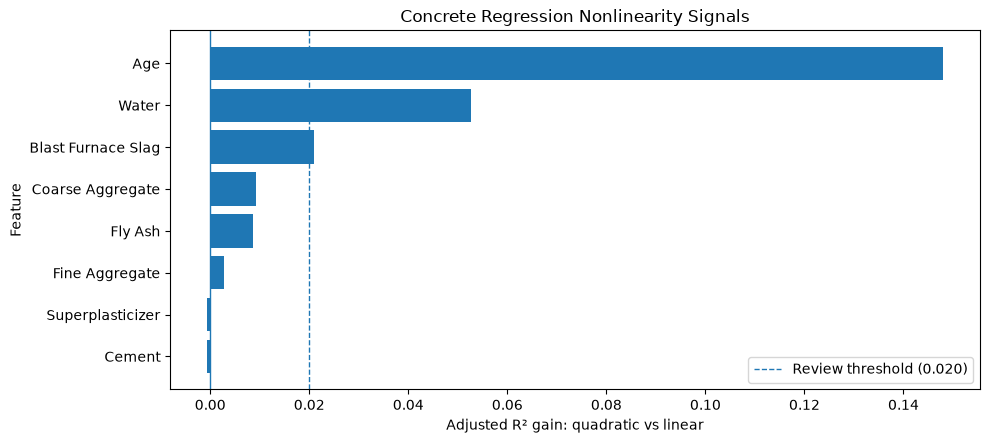

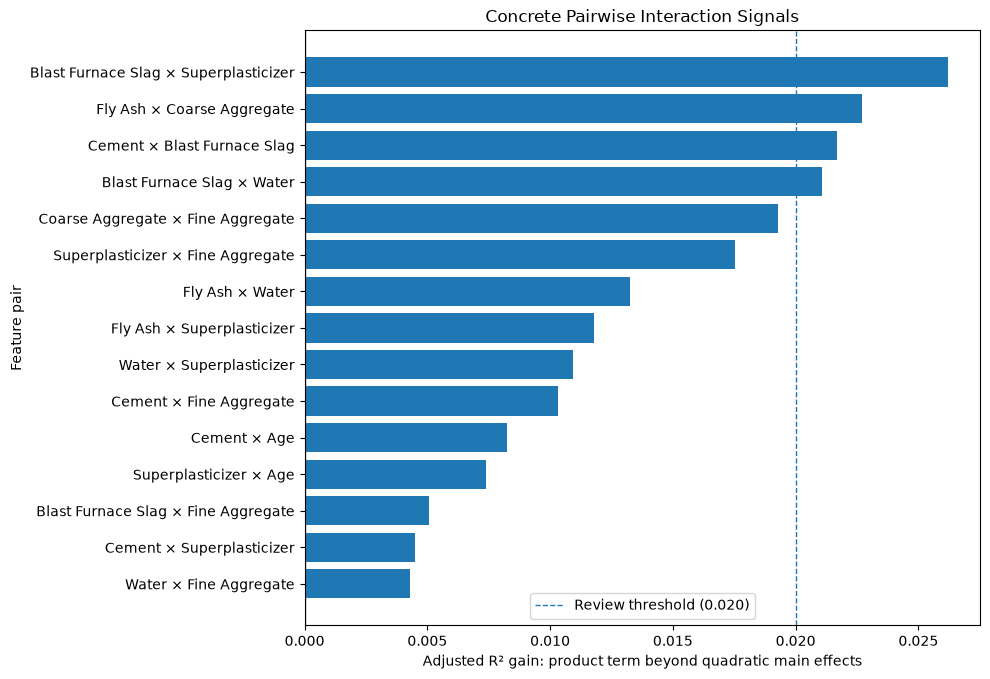

In [13]:
from scripts.analyze_regression_structure import (
    analyze_regression_structure,
    plot_interaction_signals,
    plot_nonlinearity_signals,
)
from scripts.export_figures import export_figure


# Exploratory structural thresholds; these do not select models or features.
NONLINEARITY_REVIEW_THRESHOLD = 0.02
INTERACTION_REVIEW_THRESHOLD = 0.02
INTERACTION_REVIEW_LIMIT = 15

regression_structure_report = analyze_regression_structure(
    df,
    features=NUMERICAL_FEATURES,
    target=target_contract.target,
    nonlinearity_review_threshold=NONLINEARITY_REVIEW_THRESHOLD,
    interaction_review_threshold=INTERACTION_REVIEW_THRESHOLD,
)

regression_structure_report.raise_if_invalid(
    require_features_present=True,
    require_numeric_target=True,
    require_no_missing_target=True,
    require_target_variation=True,
    require_complete_numeric_features=True,
)

display(regression_structure_report.summary_frame())
display(regression_structure_report.nonlinearity_frame())
display(
    regression_structure_report.interaction_frame(
        limit=INTERACTION_REVIEW_LIMIT,
    )
)

nonlinearity_figure = plot_nonlinearity_signals(
    regression_structure_report,
    title="Concrete Regression Nonlinearity Signals",
)
export_figure(
    nonlinearity_figure,
    PROJECT.root / "docs/images/regression_nonlinearity_signals.png",
)
display(nonlinearity_figure)

interaction_figure = plot_interaction_signals(
    regression_structure_report,
    limit=INTERACTION_REVIEW_LIMIT,
    title="Concrete Pairwise Interaction Signals",
)
export_figure(
    interaction_figure,
    PROJECT.root / "docs/images/regression_interaction_signals.png",
)
display(interaction_figure)

print(
    "Adjusted-R² gains are in-sample structural diagnostics only. They do not "
    "estimate future predictive performance, establish causality, select "
    "features, or prescribe polynomial/interaction engineering."
)

## 15. Potential Data Leakage and Derived-Feature Dependencies

In [14]:
from scripts.analyze_leakage import (
    analyze_static_continuous_regression_leakage,
)


# UCI documents the retained inputs as mixture components plus curing age.
# No retained feature is source-documented as a mathematical transform of
# another retained input, so no derived dependency is asserted here.
DERIVED_FEATURE_DEPENDENCIES = ()

# Numerical tolerances are used only to detect near-exact target reproductions.
LEAKAGE_NUMERIC_RELATIVE_TOLERANCE = 1e-8
LEAKAGE_NUMERIC_ABSOLUTE_TOLERANCE = 1e-10
LEAKAGE_DEPENDENCY_CONFIRMATION_RATE = 0.99

leakage_report = analyze_static_continuous_regression_leakage(
    df,
    target=target_contract.target,
    candidate_features=FEATURE_COLUMNS,
    identifiers=IDENTIFIER_COLUMNS,
    derived_dependencies=DERIVED_FEATURE_DEPENDENCIES,
    relative_tolerance=LEAKAGE_NUMERIC_RELATIVE_TOLERANCE,
    absolute_tolerance=LEAKAGE_NUMERIC_ABSOLUTE_TOLERANCE,
    confirmation_rate=LEAKAGE_DEPENDENCY_CONFIRMATION_RATE,
)

leakage_report.raise_if_invalid()

display(leakage_report.summary_frame())

dependency_audit = leakage_report.dependency_frame()
if dependency_audit.empty:
    print(
        "No source-documented retained derived-feature dependency is declared "
        "for this dataset."
    )
else:
    display(dependency_audit)

if leakage_report.has_target_proxy_candidates:
    print("Potential direct numerical target proxies require provenance review:")
    display(leakage_report.target_proxy_candidates_frame())
else:
    print(
        "No exact or affine numerical reproduction of the continuous target "
        "was detected among candidate features."
    )

print(
    "Feature association, nonlinearity, interaction signals, and compositional "
    "relationships are not by themselves target leakage. No feature is removed "
    "during exploration."
)

,Metric,Value,Interpretation
0,Rows audited,1030,Observations included in the static audit
1,Candidate features,8,Predictor candidates reviewed for target leakage
2,Source identifiers,0,Identifier fields kept outside predictor seman...
3,Target proxy candidates,0,Exact or affine numerical target encodings det...
4,Declared derived dependencies,0,Source-backed mathematical feature dependencie...
5,Confirmed derived dependencies,0,Features numerically reproduced from retained ...
6,External-source dependencies,0,Documented derived features requiring an omitt...
7,Target-derived dependencies,0,Derived features whose declared formula uses t...
8,Direct target leakage detected,False,No direct target leakage evidence found


No source-documented retained derived-feature dependency is declared for this dataset.
No exact or affine numerical reproduction of the continuous target was detected among candidate features.
Feature association, nonlinearity, interaction signals, and compositional relationships are not by themselves target leakage. No feature is removed during exploration.


## 16. Initial Data-Quality Findings

In [15]:
from scripts.consolidate_quality_findings import (
    consolidate_initial_data_quality_from_reports,
)


quality_findings_report = consolidate_initial_data_quality_from_reports(
    available_fields=df.columns,
    row_count=len(df),
    domain_report=domain_report,
    value_quality_report=value_quality_report,
    duplicate_report=duplicate_report,
    target_report=target_distribution_report,
    numerical_report=numerical_report,
    leakage_report=leakage_report,
    problem_type=PROBLEM_TYPE,
)

# Preparation actions are intentionally defined later, in stage 18.
quality_findings_report.raise_if_invalid(
    require_action_for_open_findings=False,
)

display(quality_findings_report.quality_overview_frame())

initial_quality_findings = quality_findings_report.findings_frame()
if initial_quality_findings.empty:
    print("No initial data-quality finding requires review or resolution.")
else:
    display(initial_quality_findings)
    display(quality_findings_report.evidence_frame())

display(quality_findings_report.validated_non_issues_frame())

,Metric,Value,Interpretation
0,Dataset rows,1030,Rows represented by the consolidated audit
1,Consolidated findings,4,Conditions requiring review or resolution
2,Open or review findings,4,"Findings still open, monitored, or under review"
3,Blocking findings,3,Unresolved findings with a declared blocking s...
4,Validated non-issues,5,Conditions protected from unnecessary cleaning
5,Structural consolidation valid,True,Finding and evidence references are coherent


,Finding ID,Domain,Title,Affected fields,Affected field count,Severity,Status,Disposition,Blocking scope,Source stages,Required action,Verification
0,DQ-001,Schema and domain validity,Source-backed type or domain constraints requi...,"(Blast Furnace Slag,)",1,High,Open,Must fix,Preparation,"(7,)",Resolve every source-type mismatch and declare...,The type/domain audit reports zero mismatched ...
1,DQ-002,Value quality,Missing or invalid values require deterministi...,"(Blast Furnace Slag,)",1,High,Open,Must fix,Preparation,"(8,)",Define evidence-backed handling for each affec...,The prepared projection passes the same value-...
2,DQ-003,Record integrity,Exact row matches require review because sourc...,(),0,Medium,Review,Monitor,None,"(9,)",Preserve exact row matches unless independent ...,Any later deduplication decision cites source-...
3,DQ-004,Record ambiguity,Identical feature profiles occur with differen...,(),0,Medium,Review,Evaluate,Model evaluation,"(9,)",Retain the records and quantify their effect d...,Model evaluation documents whether repeated pr...


,Evidence ID,Finding ID,Source report,Source metric,Observed value,Expected value,Interpretation
0,DQ-001-E01,DQ-001,domain_report,Type mismatches,1,0,Observed dtypes must satisfy source-backed sem...
1,DQ-001-E02,DQ-001,domain_report,Columns with domain violations,0,0,Declared per-column domain rules must hold.
2,DQ-001-E03,DQ-001,domain_report,Relations with violations,0,0,Declared cross-column physical relations must ...
3,DQ-002-E01,DQ-002,value_quality_report,Missing count,0,0,Observed issue count from the source-backed va...
4,DQ-002-E02,DQ-002,value_quality_report,Blank count,0,0,Observed issue count from the source-backed va...
5,DQ-002-E03,DQ-002,value_quality_report,Inconsistent count,0,0,Observed issue count from the source-backed va...
6,DQ-002-E04,DQ-002,value_quality_report,Invalid count,298,0,Observed issue count from the source-backed va...
7,DQ-003-E01,DQ-003,duplicate_report,Exact duplicate groups,11,Review only,The dataset does not provide source identifier...
8,DQ-003-E02,DQ-003,duplicate_report,Exact duplicate rows,36,Review only,Exact equality cannot establish repeated physi...
9,DQ-004-E01,DQ-004,duplicate_report,Target-conflict profile groups,9,0,Identical predictors mapping to different nume...


,Non-issue ID,Domain,Title,Affected fields,Affected field count,Source stages,Evidence,Disposition,Interpretation
0,NI-008,Derived-feature provenance,No source-documented retained derived-feature ...,(),0,"(15,)",The retained Concrete predictors are source-de...,No action,Do not invent derived-feature dependencies fro...
1,NI-007,Leakage governance,No direct or deterministic target leakage was ...,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",8,"(15,)",The target is excluded from candidate predicto...,No action,Preserve target isolation in every downstream ...
2,NI-006,Numerical distribution,IQR outlier candidates are not automatically i...,"(Blast Furnace Slag, Water, Superplasticizer, ...",5,"(11,)",5 feature(s) contain 85 feature-level IQR cand...,Preserve,"Do not remove, clip, or winsorize observations..."
3,NI-005,Target distribution,"Target extremes are distributional evidence, n...","(Concrete compressive strength,)",1,"(10,)",Observed range: 2.33 to 82.6; values outside 1...,Preserve,"Do not clip, winsorize, remove, or transform t..."
4,NI-004,Target integrity,"The continuous regression target is complete, ...","(Concrete compressive strength,)",1,"(10,)",Finite observations: 1030; distinct finite tar...,No action,Preserve the response on its original continuo...


## 17. Key Exploratory Insights

In [16]:
from scripts.consolidate_exploratory_insights import (
    consolidate_continuous_regression_key_exploratory_insights_from_reports,
)


exploratory_insights_report = (
    consolidate_continuous_regression_key_exploratory_insights_from_reports(
        available_fields=df.columns,
        quality_report=quality_findings_report,
        target_report=target_distribution_report,
        numerical_report=numerical_report,
        feature_relationship_report=feature_relationship_report,
        feature_target_report=feature_target_report,
        regression_structure_report=regression_structure_report,
        leakage_report=leakage_report,
    )
)

exploratory_insights_report.raise_if_invalid()

display(exploratory_insights_report.exploratory_overview_frame())
display(exploratory_insights_report.key_insights_frame())

exploratory_hypotheses = exploratory_insights_report.hypotheses_frame()
if not exploratory_hypotheses.empty:
    print(
        "The following hypotheses remain exploratory and must be validated "
        "in later modeling stages."
    )
    display(exploratory_hypotheses)

display(exploratory_insights_report.limitations_frame())

,Metric,Value,Interpretation
0,Key exploratory insights,6,Evidence-backed conclusions synthesized from p...
1,High-relevance insights,5,Insights prioritized for downstream validation
2,Exploratory hypotheses,1,Testable explanations deferred to later notebooks
3,Validation actions,1,Planned checks linked to exploratory hypotheses
4,Interpretation limitations,1,Boundaries that prevent overclaiming from EDA
5,Structural consolidation valid,True,"Insight, evidence, and reference contracts are..."
6,Ready for preparation decisions,True,Stage-17 evidence can inform preparation decis...


,Insight ID,Theme,Title,Relevance,Status,Summary,Modeling implication,Interpretation boundary
0,INS-001,Data quality,Data-quality conditions require targeted review,High,Unresolved,"Stage 16 consolidated 4 findings, 3 blockers, ...",Restrict preparation to evidence-backed action...,Structural data quality does not establish reg...
1,INS-002,Target distribution,Continuous target scale and extremes define th...,High,Observed,Observed target range=80.2700 MPa; mean=35.818...,Evaluate regression error on the original targ...,Target spread and Tukey-fence extremes describ...
2,INS-005,Feature-to-target association,Numerical inputs show measurable univariate as...,High,Observed,4 features meet the exploratory association th...,Retain the validated inputs for the baseline a...,"Univariate association is not causality, incre..."
3,INS-006,Regression structure,Exploratory diagnostics indicate nonlinear or ...,High,Observed,Nonlinearity signals=3; interaction signals=4;...,Compare a transparent additive baseline with m...,Adjusted-R² gains are in-sample structural dia...
4,INS-007,Leakage governance,No direct numerical target leakage was detecte...,High,Controlled,Direct target leakage=False; target proxy cand...,Keep target semantics isolated and preserve le...,Absence of static target proxies does not repl...
5,INS-003,Numerical distributions,IQR candidates occur in numerical feature dist...,Medium,Observed,5 features contain IQR review candidates (cand...,Keep raw observations and compare robustness o...,"IQR candidates are statistical extremes, not p..."


The following hypotheses remain exploratory and must be validated in later modeling stages.


,Hypothesis ID,Linked insight IDs,Linked insight count,Title,Hypothesis,Status,Confounding risks,Confounding risk count,Required validation,Decision stage,Validation action count
0,HYP-002,"(INS-006,)",1,Flexible regression families may improve on a ...,Model families that can represent nonlinear ef...,Unvalidated,"(In-sample diagnostic optimism, Feature scale ...",2,Compare additive linear and flexible candidate...,Model selection,1


,Limitation ID,Theme,Title,Limitation type,Affected fields,Affected field count,Severity,Status,Source stages,Implication,Required resolution
0,LIM-001,Exploratory interpretation,EDA associations and structural fits do not es...,Modeling,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",9,Contextual,Accepted,"(12, 13, 14, 17)","Correlation, adjusted-R² gains, redundancy sig...",Validate predictive claims with leakage-safe c...


## 18. Preparation Decisions

In [17]:
from IPython.display import display

from scripts.record_preparation_decisions import (
    record_static_continuous_regression_preparation_decisions,
)


# Dataset-study preparation policy remains explicit in the notebook.
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15
PREPARATION_RANDOM_SEED = 42

# The released UCI values are authoritative for materialization. The source
# metadata labels Blast Furnace Slag as Integer even though valid decimal
# measurements are present, so the analytical type is resolved without
# rounding, truncating, deleting, or imputing released values.
SOURCE_TYPE_RESOLUTIONS = {
    "Blast Furnace Slag": {
        "source_declared_type": "Integer",
        "effective_analytical_type": "Continuous numeric",
        "operation": (
            "Preserve released decimal values exactly; do not round, truncate, "
            "or coerce them to integer."
        ),
        "rationale": (
            "The acquired UCI table contains domain-valid decimal slag quantities, "
            "so the released measurements take precedence over the incompatible "
            "source-type annotation."
        ),
    },
}

preparation_decision_report = (
    record_static_continuous_regression_preparation_decisions(
        available_fields=df.columns,
        target=target_contract.target,
        candidate_features=FEATURE_COLUMNS,
        identifiers=IDENTIFIER_COLUMNS,
        duplicate_report=duplicate_report,
        target_report=target_distribution_report,
        numerical_report=numerical_report,
        feature_relationship_report=feature_relationship_report,
        regression_structure_report=regression_structure_report,
        leakage_report=leakage_report,
        quality_report=quality_findings_report,
        exploratory_insights_report=exploratory_insights_report,
        source_type_resolutions=SOURCE_TYPE_RESOLUTIONS,
        train_fraction=TRAIN_FRACTION,
        validation_fraction=VALIDATION_FRACTION,
        test_fraction=TEST_FRACTION,
        random_seed=PREPARATION_RANDOM_SEED,
    )
)

preparation_decision_report.raise_if_invalid()
preparation_decision_report.raise_if_split_not_ready(
    require_stratification_contract=False,
)

display(preparation_decision_report.summary_frame())
display(preparation_decision_report.decisions_frame())
display(preparation_decision_report.execution_plan_frame())
display(preparation_decision_report.split_policy_frame())
display(preparation_decision_report.guardrails_frame())

preparation_blockers = preparation_decision_report.blockers_frame()
if preparation_blockers.empty:
    print("No preparation or split-execution blocker remains open.")
else:
    display(preparation_blockers)

print(
    "Preparation decisions are declarations only; no source values were changed, "
    "no split was executed, no transformer was fitted, and no model was trained."
)

,Metric,Value,Interpretation
0,Declared fields,9,Fields available to preparation decisions
1,Preparation decisions,10,"Versioned cleaning, transformation, engineerin..."
2,Approved decisions,6,Decisions authorized within their declared scope
3,Conditional decisions,1,Decisions requiring a later model or contract ...
4,Deferred decisions,2,Candidates intentionally postponed to evaluation
5,Prohibited decisions,1,Operations explicitly excluded from preparation
6,Blocked decisions,0,Decisions awaiting unresolved prerequisites
7,Evidence records,10,Traceable support for decisions
8,Execution steps,5,Ordered future implementation plan
9,Guardrails,9,Explicit prohibitions protecting preparation i...


,Decision ID,Domain,Title,Affected fields,Affected field count,Status,Phase,Fit scope,Operation,Rationale,Prerequisites,Prerequisite count,Acceptance criteria,Source stages,Evidence count,Execution step count
0,PREP-003,Cleaning,Prohibit unsupported deduplication and generic...,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",9,Prohibited,Before split,None,Do not drop exact row matches without independ...,"The source provides no observation identifier,...",(),0,No row or value is altered by equality-only de...,"(9, 10, 11, 16, 17)",1,2
1,PREP-001,Cleaning,Resolve source-type metadata conflicts without...,"(Blast Furnace Slag,)",1,Approved,Before split,Deterministic,Blast Furnace Slag: Preserve released decimal ...,Blast Furnace Slag: The acquired UCI table con...,(),0,Every declared source-type conflict has an exp...,"(7, 8, 16, 17)",1,2
2,PREP-002,Cleaning,Preserve the validated source observations,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",9,Approved,Before split,Deterministic,Create a defensive prepared copy that preserve...,"No missing, non-finite, domain-invalid, or lea...","(PREP-001,)",1,Prepared row count and numerical values match ...,"(7, 8, 15, 16)",1,2
3,PREP-004,Target governance,Preserve the continuous target on its original...,"(Concrete compressive strength,)",1,Approved,Before split,None,Keep the regression target numeric and continu...,The analytical contract is continuous regressi...,(),0,Prepared y preserves the released numeric targ...,"(5, 10, 15, 17)",1,2
4,PREP-005,Feature role,Use the complete validated candidate-feature s...,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",8,Approved,Before split,None,Start downstream regression evaluation with al...,"Exploratory association, redundancy, curvature...",(),0,Baseline X contains exactly the declared candi...,"(6, 12, 13, 14, 15, 17)",1,2
5,PREP-006,Dataset splitting,Use a reproducible non-stratified snapshot split,"(Concrete compressive strength,)",1,Approved,Split,None,Partition the validated snapshot into 70% trai...,The analytical table has no chronological eval...,"(PREP-002, PREP-004)",2,Partitions are reproducible and disjoint; the ...,"(10, 15, 17)",1,2
6,PREP-010,Leakage governance,Split before every learned target-aware or dis...,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",9,Approved,Split,None,Perform the approved split before fitting scal...,Held-out partitions must not influence learned...,"(PREP-006,)",1,All learned operations record train-only fit s...,"(15, 17)",1,2
7,PREP-007,Transformation,Make numerical scaling model-dependent and tra...,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",8,Conditional,Train-only transformation,Train only,Preserve released numerical values and fit sca...,"All predictors are numerical, but sensitivity ...","(PREP-006,)",1,Any scaler is fitted on training data only; va...,"(7, 11, 15, 17)",1,2
8,PREP-008,Feature engineering,Defer nonlinear and interaction representation...,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",8,Deferred,Model selection,Evaluation only,Compare a transparent additive baseline with c...,Exploration flagged 3 nonlinearity signal(s) a...,"(PREP-005, PREP-006)",2,Nonlinear or interaction-aware alternatives ar...,"(14, 17)",1,2
9,PREP-009,Feature engineering,Carry repeated-profile ambiguity into model-ev...,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",9,Deferred,Model selection,Evaluation only,Preserve repeated observations in the baseline...,Exploration found 19 repeated feature-profile ...,"(PREP-003, PREP-006)",2,Any repeated-profile sensitivity analysis is r...,"(9, 16, 17)",1,2


,Step ID,Sequence,Decision IDs,Decision count,Phase,Action,Blocking,Status,Temporal dependency,Acceptance criteria
0,STEP-001,1,"(PREP-001, PREP-002, PREP-003, PREP-004, PREP-...",5,Before split,"Revalidate the raw table, apply only the decla...",True,Planned,False,Source row count and numerical values are pres...
1,STEP-002,2,"(PREP-006, PREP-010)",2,Split,"Create reproducible non-stratified train, vali...",True,Planned,False,"Partitions are disjoint, reproducible, preserv..."
2,STEP-003,3,"(PREP-007,)",1,Train-only transformation,Fit model-dependent numerical preprocessing on...,True,Planned,False,Validation and test are transform-only and no ...
3,STEP-004,4,"(PREP-008, PREP-009)",2,Model selection,"Evaluate nonlinear structure, repeated-profile...",False,Deferred,False,Alternatives are adopted only from leakage-saf...
4,STEP-005,5,"(PREP-001, PREP-002, PREP-003, PREP-004, PREP-...",10,Model selection,"Freeze preprocessing, feature policy, target h...",True,Deferred,False,Final test data are accessed only after all mo...


,Policy item,Value,Status,Interpretation
0,Train fraction,0.7,Resolved,Provisional share allocated to model fitting
1,Validation fraction,0.15,Resolved,Provisional share reserved for model selection
2,Test fraction,0.15,Resolved,Final holdout share reserved for one-time eval...
3,Stratification field,None,Resolved,No stratification is applied in the random fal...
4,Random seed,42,Resolved,Seed used only for reproducible random fallback
5,Shuffle random split,True,Resolved,Random fallback shuffles rows before partitioning
6,Temporal split priority,True,Resolved,Chronological partitioning overrides random fa...
7,Temporal policy status,Resolved snapshot fallback,Resolved,Temporal partition strategy has an explicit re...
8,Random-split fallback,Approved for this source-released static conti...,Resolved,Condition required before using the provisiona...
9,Final test holdout,True,Resolved,The final test set is excluded from all fittin...


,Guardrail ID,Domain,Title,Affected fields,Affected field count,Severity,Status,Prohibited operation,Rationale,Verification
0,GRD-001,Cleaning,Preserve the raw evidence,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",9,Critical,Active,Modify or overwrite the acquired raw table in ...,Reproducible preparation requires immutable so...,"Raw shape, values, index, and dtypes remain un..."
1,GRD-002,Cleaning,Do not coerce released decimals to satisfy sou...,"(Blast Furnace Slag,)",1,Critical,Active,"Round, truncate, or coerce released decimal me...",The explicit source-type resolution changes an...,Prepared values remain numerically identical t...
2,GRD-005,Target governance,Keep the continuous target outside predictors,"(Concrete compressive strength,)",1,Critical,Active,Include the target or a direct numerical deriv...,This would constitute direct target leakage.,Predictor matrices contain exactly candidate f...
3,GRD-007,Leakage governance,Fit learned preprocessing on training only,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",8,Critical,Active,"Fit scaling, selection, target transformation,...",Held-out data must not influence learned prepa...,Every learned transformer records train-only f...
4,GRD-008,Feature engineering,Do not select features globally,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",8,Critical,Active,"Use full-data target associations, nonlinearit...",Global selection would bias held-out evaluation.,Ablation and selection use training/validation...
5,GRD-009,Dataset splitting,Protect the final test holdout,"(Concrete compressive strength,)",1,Critical,Active,"Use final-test metrics for model, feature, tra...",Repeated test access converts the final holdou...,Final test evaluation occurs only after the an...
6,GRD-003,Cleaning,Do not deduplicate from row equality alone,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",9,High,Active,Drop exact matches without independent observa...,The released table does not provide a source o...,No source row is removed solely because releas...
7,GRD-004,Cleaning,Do not apply generic outlier cleaning,"(Cement, Blast Furnace Slag, Fly Ash, Water, S...",9,High,Active,"Delete, clip, winsorize, or replace values sol...","IQR and target-extreme flags are descriptive, ...",The baseline prepared projection preserves eve...
8,GRD-006,Target governance,Do not manufacture target classes for preparation,"(Concrete compressive strength,)",1,High,Active,Discretize the continuous target into bins as ...,The declared problem is continuous regression ...,"Prepared y remains numeric, continuous, and un..."


No preparation or split-execution blocker remains open.
Preparation decisions are declarations only; no source values were changed, no split was executed, no transformer was fitted, and no model was trained.


## 19. Handoff and Next Steps

In [18]:
from IPython.display import display

from scripts.build_exploration_handoff import (
    build_static_continuous_regression_exploration_handoff,
    load_and_validate_exploration_handoff,
)


EXPLORATION_HANDOFF_FILE = PROJECT.path(
    "artifacts",
    "exploration",
    DATASET_SLUG,
    "exploration-handoff.json",
)

exploration_handoff_report = (
    build_static_continuous_regression_exploration_handoff(
        dataset_slug=DATASET_SLUG,
        source_repository="UCI Machine Learning Repository",
        source_dataset_id=UCI_DATASET_ID,
        source_file=DATASET_FILE,
        project_root=PROJECT.root,
        source_dataframe=df,
        target_contract=target_contract,
        feature_columns=FEATURE_COLUMNS,
        numerical_features=NUMERICAL_FEATURES,
        identifier_columns=IDENTIFIER_COLUMNS,
        target_report=target_distribution_report,
        duplicate_report=duplicate_report,
        feature_relationship_report=feature_relationship_report,
        leakage_report=leakage_report,
        quality_report=quality_findings_report,
        insights_report=exploratory_insights_report,
        preparation_report=preparation_decision_report,
    )
)

exploration_handoff_report.raise_if_invalid()
persisted_handoff = exploration_handoff_report.write(EXPLORATION_HANDOFF_FILE)

reloaded_handoff = load_and_validate_exploration_handoff(
    persisted_handoff.path,
    expected_dataset_slug=DATASET_SLUG,
    expected_source_dataset_id=UCI_DATASET_ID,
)
assert reloaded_handoff["source"]["sha256"] == (
    exploration_handoff_report.payload["source"]["sha256"]
)

display(exploration_handoff_report.summary_frame())

open_reviews = exploration_handoff_report.open_reviews_frame()
if not open_reviews.empty:
    print("Non-blocking reviews carried forward:")
    display(open_reviews)

display(exploration_handoff_report.next_steps_frame())
display(exploration_handoff_report.expected_outputs_frame())

print(f"Persisted handoff: {PROJECT.display(persisted_handoff.path)}")
print(f"SHA-256: {persisted_handoff.sha256}")
print(
    "Notebook 01 is complete. Notebook 02 must reload and revalidate the "
    "source from a fresh kernel before materializing preparation artifacts. "
    "Model selection remains blocked until Notebook 02 publishes validated "
    "and sealed partitions."
)

,Gate,Ready,Interpretation
0,Notebook 01 analysis complete,True,"Exploration, quality, leakage, insight, and de..."
1,Handoff artifact structurally valid,True,"Serialized source, role, evidence, and continu..."
2,Deterministic preparation may begin,True,Notebook 02 may independently reconstruct and ...
3,Snapshot split may execute,True,The 70/15/15 shuffled non-stratified snapshot ...
4,Model selection may begin,False,Expected to remain false until Notebook 02 pub...
5,Notebook 01 handoff ready,True,Notebook 02 can continue from a fresh kernel u...


Non-blocking reviews carried forward:


,review_id,theme,blocking,summary,continuation
0,REV-001,Duplicate identity,False,11 exact-row group(s) covering 36 rows exist w...,"Preserve rows. During partition validation, re..."
1,REV-HYP-001,Exploratory hypothesis,False,Model families that can represent nonlinear ef...,Compare additive linear and flexible candidate...
2,REV-003,Target extremes,False,4 target observation(s) fall outside the descr...,Preserve these observations. Later regression ...


,Notebook,Sequence,Action,Status,Acceptance criterion
0,02_data_preparation.ipynb,1,Reload the UCI source from a fresh kernel and ...,Ready,"Source dataset ID, file hash, row count, colum..."
1,02_data_preparation.ipynb,2,Reconstruct and validate the continuous-regres...,Ready,Notebook 02 does not depend on live variables ...
2,02_data_preparation.ipynb,3,Create an unchanged defensive prepared projection,Ready,All released rows and validated numerical valu...
3,02_data_preparation.ipynb,4,Separate validated predictors and the continuo...,Ready,X contains exactly the declared candidate feat...
4,02_data_preparation.ipynb,5,Execute the approved reproducible 70/15/15 sna...,Ready,"Train, validation, and test partitions are shu..."
5,02_data_preparation.ipynb,6,Validate partition integrity and continuous-ta...,Ready,Every source row occurs in exactly one partiti...
6,02_data_preparation.ipynb,7,Persist the preparation handoff and seal the f...,Ready,"Prepared data, feature manifest, split manifes..."
7,03_model_selection_and_evaluation.ipynb,1,Load and validate the frozen preparation handoff,Waiting on Notebook 02,Model selection never reconstructs partitions ...
8,03_model_selection_and_evaluation.ipynb,2,Establish regression baselines and compare can...,Waiting on Notebook 02,"All candidates use the same frozen partitions,..."
9,03_model_selection_and_evaluation.ipynb,3,"Evaluate scaling, redundancy, nonlinearity, an...",Waiting on Notebook 02,"Transformations, feature ablations, and flexib..."


,Notebook,Expected output,Purpose
0,02_data_preparation.ipynb,artifacts/preparation/concrete-compressive-str...,"Record source identity, preparation policy, an..."
1,02_data_preparation.ipynb,artifacts/preparation/concrete-compressive-str...,"Freeze feature order, continuous-target semant..."
2,02_data_preparation.ipynb,artifacts/preparation/concrete-compressive-str...,Prove the reproducible non-stratified partitio...
3,02_data_preparation.ipynb,artifacts/preparation/concrete-compressive-str...,Prove post-preparation integrity and source pr...
4,03_model_selection_and_evaluation.ipynb,artifacts/model-selection/concrete-compressive...,Freeze the selected regression candidate and d...


Persisted handoff: artifacts/exploration/concrete-compressive-strength/exploration-handoff.json
SHA-256: 91f9e9349c81db1aa041e307898c6811f2e5c421c99a64e6637dc1db49465387
Notebook 01 is complete. Notebook 02 must reload and revalidate the source from a fresh kernel before materializing preparation artifacts. Model selection remains blocked until Notebook 02 publishes validated and sealed partitions.
